# Teaching Assistant Info
- Davide Sferrazza
- davide.sferrazza@polito.it

# Lab 5: Transfer Learning and Visualizations
> **Note:** There may be more than one solution to each of the exercises, don't worry too much about the *exact* right answer. Try to write some code that works first and then improve it if you can.



## Step 1: Install missing dependencies and import libraries

In [1]:
%%capture
# Install missing dependencies
!pip install -q torchinfo torchmetrics tensorboard

In [ ]:
# Import required libraries/code
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

from torch import nn
from torch.utils.tensorboard import SummaryWriter
from torchvision import transforms, datasets

from torchinfo import summary

import os, tqdm

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

In [3]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## Step 2: plot a confusion matrix of the predictions on the test set

### Get data

In [4]:
%%capture
!wget https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip
!mkdir -p data
!unzip -n pizza_steak_sushi.zip -d data/pizza_steak_sushi

### Prepare data

In [5]:
# Create a transforms pipeline
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # 1. Reshape all images to 224x224 (though some models may require different sizes)
    transforms.ToTensor(),  # 2. Turn image values to between 0 & 1
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # 3. A mean of [0.485, 0.456, 0.406] (across each color channel)
                         std=[0.229, 0.224, 0.225])  # 4. A standard deviation of [0.229, 0.224, 0.225] (across each color channel),
])

In [6]:
# Create training and testing DataLoader's as well as get a list of class names

data_path = "data/pizza_steak_sushi"
train_dset = ImageFolder(f"{data_path}/train", transform=simple_transform)
test_dset = ImageFolder(f"{data_path}/test", transform=simple_transform)
class_names = list(os.listdir(f"{data_path}/train"))  # 'pizza', 'steak', 'sushi'
print(f"Class names: {class_names}")


train_dataloader = DataLoader(train_dset, batch_size=32, num_workers=0, shuffle=True)
test_dataloader = DataLoader(test_dset, batch_size=32, num_workers=0)

# train_dataloader, test_dataloader, class_names

Class names: ['steak', 'sushi', 'pizza']


### Get and prepare a pretrained model

In [7]:
# Setup the model with pretrained weights and send it to the target device
from torchvision.models import efficientnet_b0
from torchvision.models import EfficientNet_B0_Weights

model_0 = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1).to(device)
# model_0  # or summary(model_0, (3, 224, 224)) # uncomment to output (it's very long)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 153MB/s]


In [8]:
# Freeze all base layers in the "features" section of the model (the feature extractor) by setting requires_grad=False
for param in model_0.features.parameters():
    param.requires_grad = False

In [9]:
# Set the manual seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Get the length of class_names (one output unit for each class)
out_features = len(class_names)

# Get the number of input features to classification layer
in_features = model_0.classifier[-1].in_features

# Recreate the classifier layer and seed it to the target device
model_0.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(
        in_features=in_features,
        out_features=out_features, # same number of output units as our number of classes
        bias=True
    )
).to(device)

### Train model

In [10]:
# Define loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(), lr=1e-3)

In [11]:
from tqdm.auto import tqdm

def train(model, optimizer, dataloader, loss_fn):
    # TODO
    model.train()

    train_loss, train_acc = 0, 0

    progress_bar = tqdm(
        dataloader,
        desc="Training Batch",
        leave=False
    )

    # Loop throught batches of the DataLoader
    for batch, (X, y) in enumerate(progress_bar):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_pred_class = y_pred.argmax(dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

        progress_bar.set_postfix(loss=loss.item())

    train_loss /= len(dataloader)
    train_acc /= len(dataloader)

    return train_loss, train_acc

def test(model, dataloader, loss_fn):
    # TODO
    model.eval()

    test_loss, test_acc = 0, 0

    with torch.no_grad():
        progress_bar = tqdm(
            dataloader,
            desc="Testing Batch",
            leave=False
        )

        for batch, (X, y) in enumerate(progress_bar):
            X, y = X.to(device), y.to(device)

            y_pred = model(X)

            loss = loss_fn(y_pred, y)
            test_loss += loss.item()

            y_pred_class = y_pred.argmax(dim=1)
            test_acc += (y_pred_class == y).sum().item() / len(y_pred)

            progress_bar.set_postfix(loss=loss.item())

    test_loss /= len(dataloader)
    test_acc /= len(dataloader)

    return test_loss, test_acc

In [12]:
# Set the random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# ----------------------------------
# Implement the code for TensorBoard
# ----------------------------------

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Setup training and save the results
num_epochs = 1000  # Define total number of epochs for clarity
# Use tqdm for better training tracking
pbar = tqdm(range(num_epochs), desc="Training", leave=True)

for epoch in pbar:
    # Assuming the train function returns the total loss and accuracy for the epoch
    total_loss, accuracy = train(model_0, optimizer, train_dataloader, loss_fn)
    pbar.set_postfix(total_loss=total_loss, accuracy=accuracy)

test_acc = test(model_0, test_dataloader, loss_fn)
print(f"Test accuracy: {test_acc}")  # You should get values around 90% accuracy on the test set

# End the timer and print out how long it took
end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Training Batch:   0%|          | 0/8 [00:00<?, ?it/s]

Training Batch:   0%|          | 0/8 [00:00<?, ?it/s]

Training Batch:   0%|          | 0/8 [00:00<?, ?it/s]

Training Batch:   0%|          | 0/8 [00:00<?, ?it/s]

...

Training Batch:   0%|          | 0/8 [00:00<?, ?it/s]

Training Batch:   0%|          | 0/8 [00:00<?, ?it/s]

Training Batch:   0%|          | 0/8 [00:00<?, ?it/s]

Testing Batch:   0%|          | 0/3 [00:00<?, ?it/s]

Test accuracy: (0.23717148105303446, 0.9280303030303031)
[INFO] Total training time: 1324.141 seconds


### Make a confusion matrix with the test preds and the truth labels

HINT: Look at the `torchmetrics.functional.classification.multiclass_confusion_matrix` from the torchmetrics library

Making predictions:   0%|          | 0/3 [00:00<?, ?it/s]

/tmp/ipykernel_47/2372769134.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([''] + class_names, rotation=45)
/tmp/ipykernel_47/2372769134.py:29: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([''] + class_names)


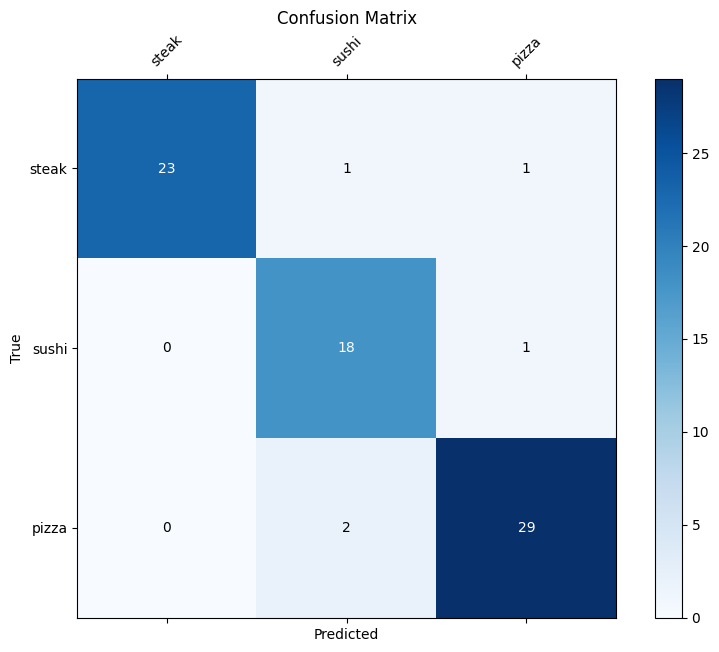

In [13]:
# TODO
from torchmetrics.classification import MulticlassConfusionMatrix
import matplotlib.pyplot as plt

y_preds = []
y_labels = []

model_0.eval()
with torch.no_grad():
    for X, y in tqdm(test_dataloader, desc="Making predictions"):
        X, y = X.to(device), y.to(device)
        y_logits = model_0(X)
        pred_labels = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)

        y_preds.append(pred_labels.cpu())
        y_labels.append(y.cpu())

y_pred_tensor = torch.cat(y_preds)
y_labels_tensor = torch.cat(y_labels)

confmat = MulticlassConfusionMatrix(num_classes=len(class_names))
confmat_tensor = confmat(preds=y_pred_tensor, target=y_labels_tensor)

fig, ax = plt.subplots(figsize=(10, 7))
cax = ax.matshow(confmat_tensor, cmap=plt.cm.Blues)
fig.colorbar(cax)

ax.set_xticklabels([''] + class_names, rotation=45)
ax.set_yticklabels([''] + class_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix')

for (i, j), z in np.ndenumerate(confmat_tensor):
    ax.text(j, i, f'{z}', ha='center', va='center',
            color='white' if z > confmat_tensor.max()/2 else 'black')

plt.show()


## Step 3: Get the "most wrong" of the predictions on the test dataset and plot the 5 "most wrong" images. You can do this by:
* Predicting across all of the test dataset, storing the labels and predicted probabilities.
* Sort the predictions by *wrong prediction* and then *descending predicted probabilities*, this will give you the wrong predictions with the *highest* prediction probabilities, in other words, the "most wrong".
* Plot the top 5 "most wrong" images, why do you think the model got these wrong?

You'll want to:
* Create a DataFrame with sample, label, prediction, pred prob
* Sort DataFrame by correct (does label == prediction)
* Sort DataFrame by pred prob (descending)
* Plot the top 5 "most wrong" image predictions

Making predictions:   0%|          | 0/3 [00:00<?, ?it/s]

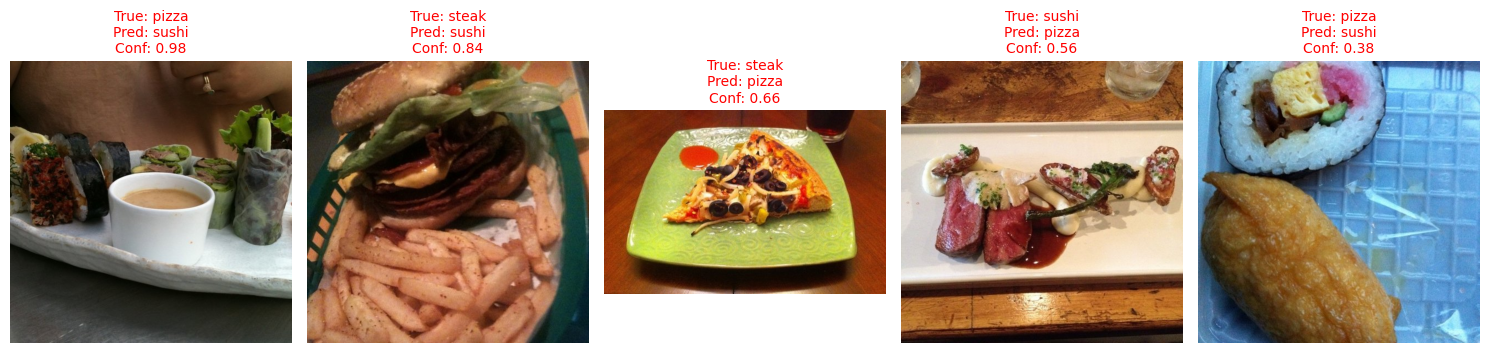

In [14]:
# TODO
import pandas as pd
import matplotlib.image as mpimg

pred_probs = []
model_0.eval()
with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc="Making predictions"):
        X = X.to(device)

        logits = model_0(X)
        probs = torch.softmax(logits, dim=1)
        pred_probs.append(probs.cpu())

pred_probs = torch.cat(pred_probs)
pred_classes = pred_probs.argmax(dim=1)
max_probs = pred_probs.max(dim=1).values

image_paths = [x[0] for x in test_dset.samples]
true_labels = [x[1] for x in test_dset.samples]

df = pd.DataFrame({
    "image_path": image_paths,
    "true_label": true_labels,
    "pred_label": pred_classes,
    "pred_prob": max_probs,
    "true_class": [class_names[i] for i in true_labels],
    "pred_class": [class_names[i] for i in pred_classes]
})

wrong_preds = df[df["true_label"] != df["pred_label"]]
most_wrong = wrong_preds.sort_values("pred_prob", ascending=False).head(5)

plt.figure(figsize=(15, 6))
for i, row in enumerate(most_wrong.itertuples()):
    ax = plt.subplot(1, 5, i+1)
    img = mpimg.imread(row.image_path)
    plt.imshow(img)
    plt.title(f"True: {row.true_class}\nPred: {row.pred_class}\nConf: {row.pred_prob:.2f}", fontsize=10, color="red")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 4: Train the model from section 4 above with more data, say 20% of the images from Food101 of Pizza, Steak and Sushi images.
* You can find the [20% Pizza, Steak, Sushi dataset](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/data/pizza_steak_sushi_20_percent.zip) on the course GitHub. It was created with the notebook [`extras/04_custom_data_creation.ipynb`](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb).


### Get 20% data

In [15]:
%%capture
!wget https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip
!mkdir -p data
!unzip pizza_steak_sushi_20_percent.zip -d data/pizza_steak_sushi_20_percent

### Create DataLoaders

In [16]:
# Create a transforms pipeline
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)), # 1. Reshape all images to 224x224 (though some models may require different sizes)
    transforms.ToTensor(), # 2. Turn image values to between 0 & 1
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # 3. A mean of [0.485, 0.456, 0.406] (across each colour channel)
                         std=[0.229, 0.224, 0.225]) # 4. A standard deviation of [0.229, 0.224, 0.225] (across each colour channel),
])

In [17]:
# Create training and testing DataLoader's as well as get a list of class names

data_path = "data/pizza_steak_sushi_20_percent"
train_dset_20p= ImageFolder(f"{data_path}/train", transform=simple_transform)
test_dset_20p = ImageFolder(f"{data_path}/test", transform=simple_transform)
class_names = list(os.listdir(f"{data_path}/train"))  # 'pizza', 'steak', 'sushi'
print(f"Class names: {class_names}")


train_dataloader_20p = DataLoader(train_dset_20p, batch_size=32, num_workers=2, shuffle=True)
test_dataloader_20p = DataLoader(test_dset_20p, batch_size=32, num_workers=2)

# train_dataloader, test_dataloader, class_names

Class names: ['steak', 'sushi', 'pizza']


### Get a pretrained model

In [18]:
# TODO
model_20p = efficientnet_b0(
    weights=EfficientNet_B0_Weights.IMAGENET1K_V1
).to(device)

for param in model_20p.features.parameters():
    param.requires_grad = False

torch.manual_seed(42)
model_20p.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(
        in_features=model_20p.classifier[-1].in_features,
        out_features=len(class_names),
        bias=True
    )
).to(device)


### Train a model with 20% of the data

In [19]:
# TODO
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_20p.parameters(), lr=1e-3)

start_time = timer()

num_epochs = 10

pbar = tqdm(
    range(num_epochs),
    desc="Training",
    leave=False
)

for epoch in pbar:
    total_loss, accuracy = train(model_20p, optimizer, train_dataloader_20p, loss_fn)
    pbar.set_postfix(total_loss=total_loss, accuracy=accuracy)

test_loss, test_acc = test(model_20p, test_dataloader_20p, loss_fn)

end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

Training:   0%|          | 0/10 [00:00<?, ?it/s]

Training Batch:   0%|          | 0/15 [00:00<?, ?it/s]

Training Batch:   0%|          | 0/15 [00:00<?, ?it/s]

Training Batch:   0%|          | 0/15 [00:00<?, ?it/s]

Training Batch:   0%|          | 0/15 [00:00<?, ?it/s]

...

Training Batch:   0%|          | 0/15 [00:00<?, ?it/s]

Training Batch:   0%|          | 0/15 [00:00<?, ?it/s]

Training Batch:   0%|          | 0/15 [00:00<?, ?it/s]

Testing Batch:   0%|          | 0/5 [00:00<?, ?it/s]

[INFO] Total training time: 27.351 seconds


## Step 5: Try a different model from [`torchvision.models`](https://pytorch.org/vision/stable/models.html) on the Pizza, Steak, Sushi data, how does this model perform?
* You'll have to change the size of the classifier layer to suit our problem.
* You may want to try an EfficientNet with a higher number than our B0, perhaps `torchvision.models.efficientnet_b2()`?
  * **Note:** Depending on the model you use you will have to prepare/transform the data in a certain way.

In [20]:
# TODO
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights

weights = EfficientNet_B2_Weights.DEFAULT
model_b2 = efficientnet_b2(weights=weights).to(device)

for param in model_b2.features.parameters():
    param.requires_grad = False

torch.manual_seed(42)

in_features = model_b2.classifier[-1].in_features
print(f"EfficientNet_B2 input features: {in_features}")

model_b2.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(in_features=in_features, out_features=3)
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_b2.parameters(), lr=1e-3)

from timeit import default_timer as timer
start_time = timer()

num_epochs = 5
print(f"Training EfficientNet_B2 on 20% data for {num_epochs} epochs...")

pbar = tqdm(range(num_epochs), desc="Training B2", leave=True)

for epoch in pbar:
    train_loss, train_acc = train(model_b2, optimizer, train_dataloader_20p, loss_fn)

    pbar.set_postfix(train_loss=f"{train_loss:.4f}", train_acc=f"{train_acc:.4f}")

test_loss, test_acc = test(model_b2, test_dataloader_20p, loss_fn)
print(f"\nFinal Test Accuracy (EfficientNet_B2): {test_acc:.4f}")

end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth
100%|██████████| 35.2M/35.2M [00:00<00:00, 176MB/s] 

EfficientNet_B2 input features: 1408
Training EfficientNet_B2 on 20% data for 5 epochs...


Training B2:   0%|          | 0/5 [00:00<?, ?it/s]

Training Batch:   0%|          | 0/15 [00:00<?, ?it/s]

Training Batch:   0%|          | 0/15 [00:00<?, ?it/s]

Training Batch:   0%|          | 0/15 [00:00<?, ?it/s]

Training Batch:   0%|          | 0/15 [00:00<?, ?it/s]

Training Batch:   0%|          | 0/15 [00:00<?, ?it/s]

Testing Batch:   0%|          | 0/5 [00:00<?, ?it/s]


Final Test Accuracy (EfficientNet_B2): 0.9284
[INFO] Total training time: 9.959 seconds
